In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("hotel_bookings.csv")

df.head()
df.shape
df.info()
df.isnull().sum()
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

In [8]:
df["booking_status"] = df["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

df["total_guests"] = df["adults"] + df["children"] + df["babies"]

df["lead_time_category"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, df["lead_time"].max()],
    labels=["Last-Minute", "Short-Term", "Medium-Term", "Long-Term"]
)

def get_season(month):
    if month in ["December", "January", "February"]:
        return "Winter"
    elif month in ["March", "April", "May"]:
        return "Spring"
    elif month in ["June", "July", "August"]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["arrival_date_month"].apply(get_season)

df["estimated_revenue"] = np.where(
    df["is_canceled"] == 0,
    df["adr"] * df["total_stay"],
    0
)

In [9]:
df = df[df["total_guests"] > 0]
df = df[df["adr"] >= 0]
df = df[df["adr"] <= 1000]
df = df[df["total_stay"] > 0]

In [10]:
df.to_csv("cleaned_hotel_bookings.csv", index=False)

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
df = pd.read_csv("cleaned_hotel_bookings.csv")

df.head()



,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,booking_status,total_stay,total_guests,lead_time_category,season,estimated_revenue
0,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,0,0,Check-Out,02-07-15,Not Canceled,1,1.0,Last-Minute,Summer,75.0
1,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,0,0,Check-Out,02-07-15,Not Canceled,1,1.0,Short-Term,Summer,75.0
2,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,0,1,Check-Out,03-07-15,Not Canceled,2,2.0,Short-Term,Summer,196.0
3,5,Resort Hotel,0,14,2015,July,27,1,0,2,...,0,1,Check-Out,03-07-15,Not Canceled,2,2.0,Short-Term,Summer,196.0
4,6,Resort Hotel,0,0,2015,July,27,1,0,2,...,0,0,Check-Out,03-07-15,Not Canceled,2,2.0,Last-Minute,Summer,214.0


In [15]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (118563, 39)

Columns:
['index', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'booking_status', 'total_stay', 'total_guests', 'lead_time_category', 'season', 'estimated_revenue']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118563 entries, 0 to 118562
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           118563 non-null  int64  
 1   hotel                           118563 non-null  object 
 2   is_canceled                     118563 non-null  int64  
 3   lead_time                       118563 non-null  int64  
 4   arrival_date_year               118563 non-null  int64  
 5   arrival_date_month              118563 non-null  object 
 6   arrival_date_week_number        118563 non-null  int64  
 7   arrival_date_day_of_month       118563 non-null  int64  
 8   stays_in_weekend_nights         118563 non-null  int64  
 9   stays_in_week_nights            118563 non-null  int64  
 10  adults                          118563 non-null  int64  
 11  children                        118563 non-null  float64
 12  babies          

In [17]:
df.describe()

,index,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay,total_guests,estimated_revenue
count,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,...,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000,118563.000000
mean,59712.464723,0.372587,104.505655,2016.157629,27.157292,15.799609,0.932078,2.512774,1.860007,0.104198,...,0.218340,74.783550,10.680533,2.333055,102.480047,0.062760,0.571941,3.444852,1.972167,219.182848
std,34441.729225,0.483495,106.915907,0.707715,13.589311,8.782205,0.995427,1.893242,0.575446,0.399122,...,0.637609,107.111401,53.719556,17.642929,47.579382,0.245745,0.793285,2.534900,0.719095,306.326032
min,2.000000,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,29940.500000,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,...,0.000000,7.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,59718.000000,0.000000,70.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,95.000000,0.000000,0.000000,3.000000,2.000000,120.000000
75%,89516.500000,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,...,0.000000,152.000000,0.000000,0.000000,126.000000,0.000000,1.000000,4.000000,2.000000,324.000000
max,119389.000000,1.000000,709.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,...,18.000000,535.000000,543.000000,391.000000,510.000000,8.000000,5.000000,69.000000,55.000000,7590.000000


In [18]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

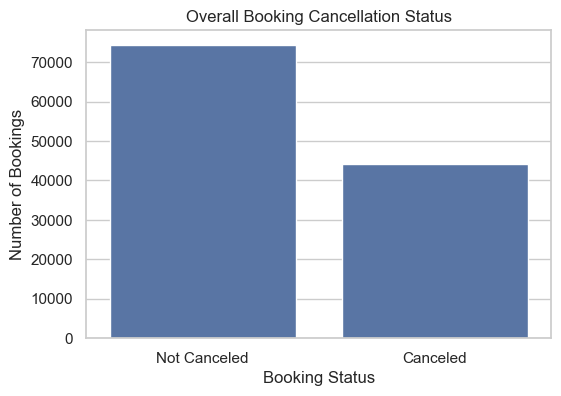

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="booking_status")
plt.title("Overall Booking Cancellation Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

In [20]:
cancellation_rate = df["is_canceled"].mean() * 100

print(f"Overall Cancellation Rate: {cancellation_rate:.2f}%")

Overall Cancellation Rate: 37.26%


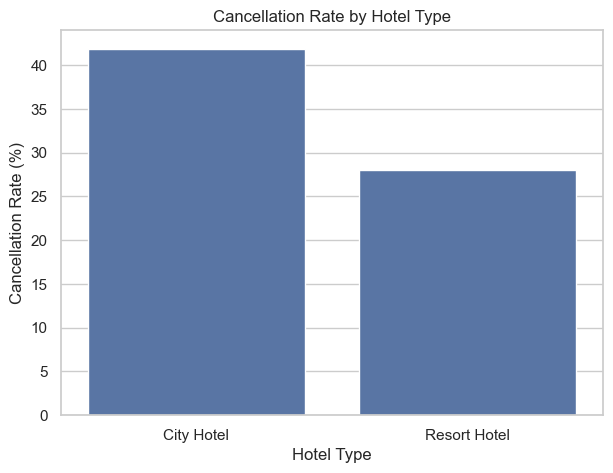

In [22]:
hotel_cancel_rate = df.groupby("hotel")["is_canceled"].mean().reset_index()
hotel_cancel_rate["cancellation_rate"] = hotel_cancel_rate["is_canceled"] * 100

hotel_cancel_rate
plt.figure(figsize=(7, 5))
sns.barplot(data=hotel_cancel_rate, x="hotel", y="cancellation_rate")
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

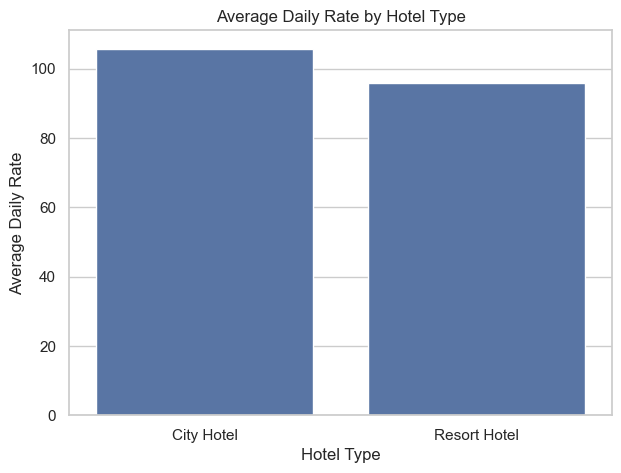

,arrival_date_month,adr
0,January,71.051628
1,February,74.214769
2,March,80.778675
3,April,100.768322
4,May,109.477708
5,June,117.168883
6,July,127.529703
7,August,140.752878
8,September,105.358074
9,October,88.671646


In [24]:
adr_by_hotel = df.groupby("hotel")["adr"].mean().reset_index()
adr_by_hotel
plt.figure(figsize=(7, 5))
sns.barplot(data=adr_by_hotel, x="hotel", y="adr")
plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")
plt.show()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

adr_by_month = df.groupby("arrival_date_month")["adr"].mean().reindex(month_order).reset_index()

adr_by_month

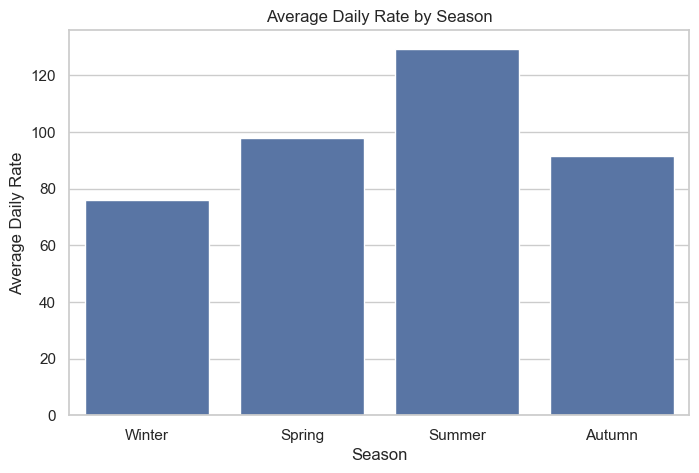

In [25]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]

adr_by_season = df.groupby("season")["adr"].mean().reindex(season_order).reset_index()

adr_by_season

plt.figure(figsize=(8, 5))
sns.barplot(data=adr_by_season, x="season", y="adr", order=season_order)
plt.title("Average Daily Rate by Season")
plt.xlabel("Season")
plt.ylabel("Average Daily Rate")
plt.show()

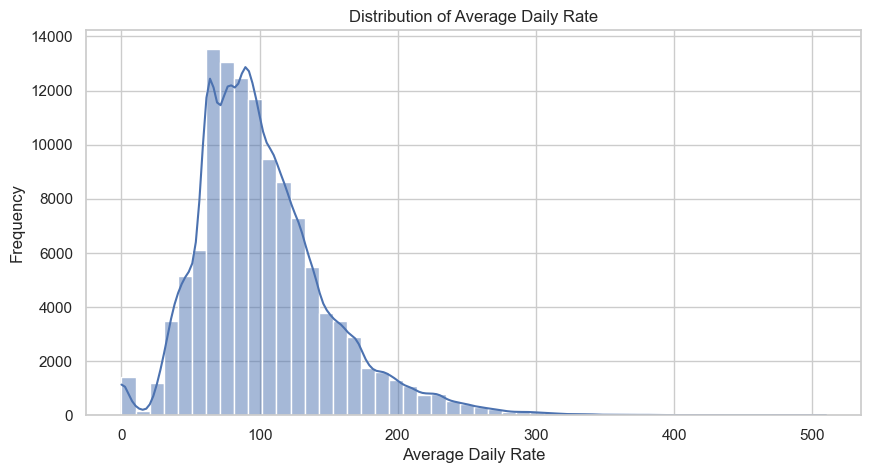

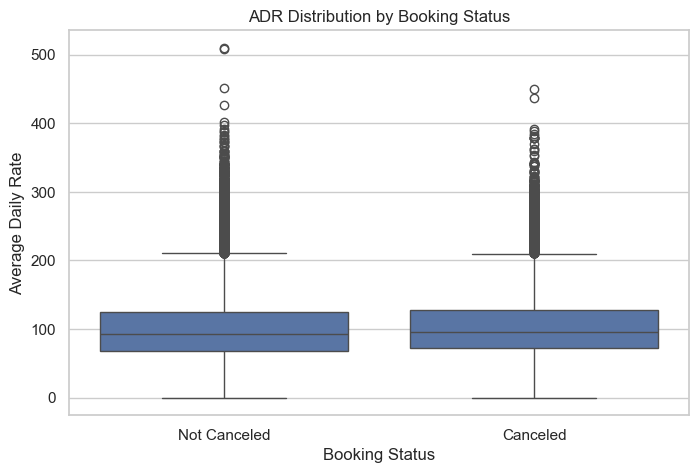

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df["adr"], bins=50, kde=True)
plt.title("Distribution of Average Daily Rate")
plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="booking_status", y="adr")
plt.title("ADR Distribution by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Daily Rate")
plt.show()

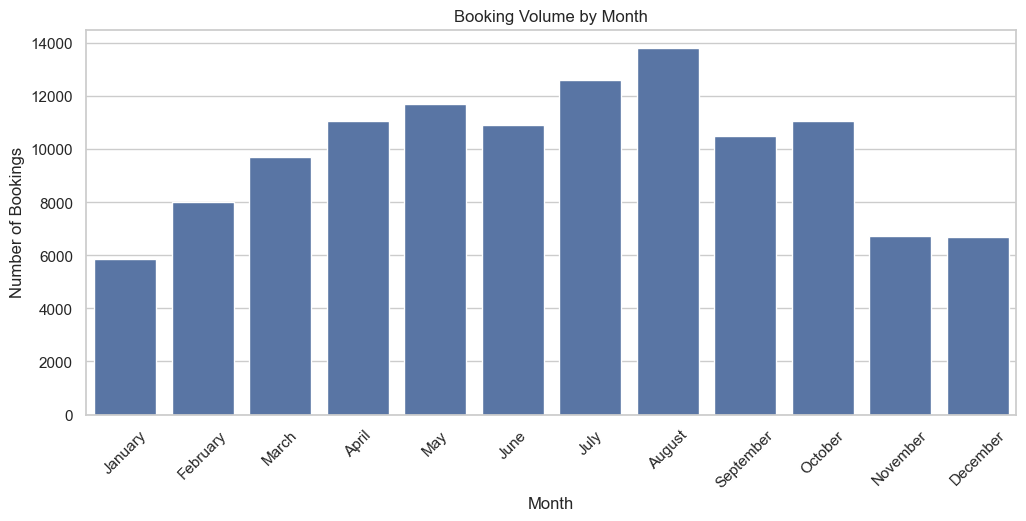

In [27]:
booking_volume_month = df["arrival_date_month"].value_counts().reindex(month_order).reset_index()
booking_volume_month.columns = ["arrival_date_month", "booking_count"]

booking_volume_month
plt.figure(figsize=(12, 5))
sns.barplot(data=booking_volume_month, x="arrival_date_month", y="booking_count")
plt.title("Booking Volume by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

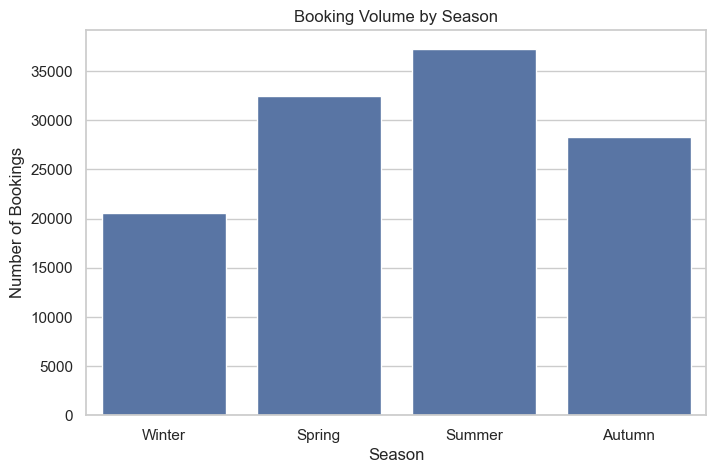

In [28]:
booking_volume_season = df["season"].value_counts().reindex(season_order).reset_index()
booking_volume_season.columns = ["season", "booking_count"]

booking_volume_season
plt.figure(figsize=(8, 5))
sns.barplot(data=booking_volume_season, x="season", y="booking_count", order=season_order)
plt.title("Booking Volume by Season")
plt.xlabel("Season")
plt.ylabel("Number of Bookings")
plt.show()

In [ ]:
monthly_summary = df.groupby("arrival_date_month").agg(
    average_adr=("adr", "mean"),
    booking_count=("hotel", "count"),
    cancellation_rate=("is_canceled", "mean")
).reindex(month_order).reset_index()

monthly_summary["cancellation_rate"] = monthly_summary["cancellation_rate"] * 100

monthly_summary
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_summary, x="arrival_date_month", y="average_adr", marker="o", label="Average ADR")
plt.title("Monthly Average ADR Trend")
plt.xlabel("Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_summary, x="arrival_date_month", y="booking_count", marker="o", label="Booking Count")
plt.title("Monthly Booking Demand Trend")
plt.xlabel("Month")
plt.ylabel("Booking Count")
plt.xticks(rotation=45)
plt.show()